# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [1]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [2]:
# YOUR CODE HERE
movie_data = pd.read_csv("https://dlsun.github.io/pods/data/ml-1m/movies.dat", sep="::", encoding_errors= "ignore", header = None, names=["MovieID", "Title", "Genres"])
movie_data.head()

<positron-console-cell-2>:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
rating_data = pd.read_csv("https://dlsun.github.io/pods/data/ml-1m/ratings.dat", sep="::", encoding_errors= "ignore", header = None, names=["UserID", "MovieID", "Rating", "Timestamp"])
rating_data.head()

<positron-console-cell-3>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [4]:
user_data = pd.read_csv("https://dlsun.github.io/pods/data/ml-1m/users.dat", sep="::", encoding_errors= "ignore", header = None, names=["UserID", "Gender", "Age", "Occupation", "Zip-code"])
user_data.head()

<positron-console-cell-4>:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


,UserID,Gender,Age,Occupation,Zip-code
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [5]:
# YOUR CODE HERE

# make a table with users and ratings, merge on UserID
rating_user_merge = user_data.merge(rating_data, on=["UserID"])
rating_user_merge.head()

,UserID,Gender,Age,Occupation,Zip-code,MovieID,Rating,Timestamp
0,1,F,1,10,48067,1193,5,978300760
1,1,F,1,10,48067,661,3,978302109
2,1,F,1,10,48067,914,3,978301968
3,1,F,1,10,48067,3408,4,978300275
4,1,F,1,10,48067,2355,5,978824291


In [6]:
# aggregate means of ratings, categorized by age group
rating_user_merge.groupby('Age')['Rating'].mean().sort_values(ascending=False)

Age
56    3.766632
50    3.714512
45    3.638062
35    3.618162
1     3.549520
25    3.545235
18    3.507573
Name: Rating, dtype: float64

3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [7]:
# YOUR CODE HERE

# filter movies to only those with >100 ratings, then sort
# rating_user_merge(["Rating"] > 100) ['Rating'].mean().sort_values(ascending=False)
# rating_user_merge[rating_user_merge["Rating"] > 100]["Rating"].mean()

# popular_movies = rating_user_merge[rating_user_merge["Rating"] > 100]
# popular_movies

# [rating_user_merge["Rating"] > 100]

# rating_user_merge[rating_user_merge["Rating"]> 100].value_counts()
# rating_user_merge

# from MovieIDs that appear 100 times or more, find thd mean rating of the MovieID
# rating_user_merge.groupby('MovieId')[rating_user_merge["Rating"] > 100]["Rating"].mean()


# Find both count and mean for each movie
movie_stats = rating_user_merge.groupby('MovieID')['Rating'].agg(['count', 'mean'])

# Filter for movies with 100 or more ratings
popular_movies_mean = movie_stats[movie_stats['count'] >= 100]['mean']

popular_movies_mean.sort_values(ascending=False)

popular_movies_mean = popular_movies_mean.sort_values(ascending=False)

compiled_data = pd.merge(popular_movies_mean, movie_data, on="MovieID")
compiled_data

,MovieID,mean,Title,Genres
0,2019,4.560510,Seven Samurai (The Magnificent Seven) (Shichin...,Action|Drama
1,318,4.554558,"Shawshank Redemption, The (1994)",Drama
2,858,4.524966,"Godfather, The (1972)",Action|Crime|Drama
3,745,4.520548,"Close Shave, A (1995)",Animation|Comedy|Thriller
4,50,4.517106,"Usual Suspects, The (1995)",Crime|Thriller
...,...,...,...,...
2014,2383,1.657718,Police Academy 6: City Under Siege (1989),Comedy
2015,2817,1.640000,Aces: Iron Eagle III (1992),Action|War
2016,3799,1.620000,Pokmon the Movie 2000 (2000),Animation|Children's
2017,3593,1.611111,Battlefield Earth (2000),Action|Sci-Fi


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

In [8]:
# YOUR CODE HERE
young_users = user_data[user_data["Age"] == 18]
young_avg = pd.merge(young_users, rating_data, on="UserID")
young_avg = young_avg.groupby('MovieID')['Rating'].agg(['count', 'mean'])
young_avg["proportion"] = young_avg["count"] / len(young_avg)
young_avg

,count,mean,proportion
MovieID,,,
1,448,4.017857,0.132037
2,154,2.993506,0.045388
3,107,3.084112,0.031536
4,39,2.512821,0.011494
5,65,2.861538,0.019157
...,...,...,...
3948,190,3.710526,0.055998
3949,82,4.219512,0.024167
3950,12,3.250000,0.003537


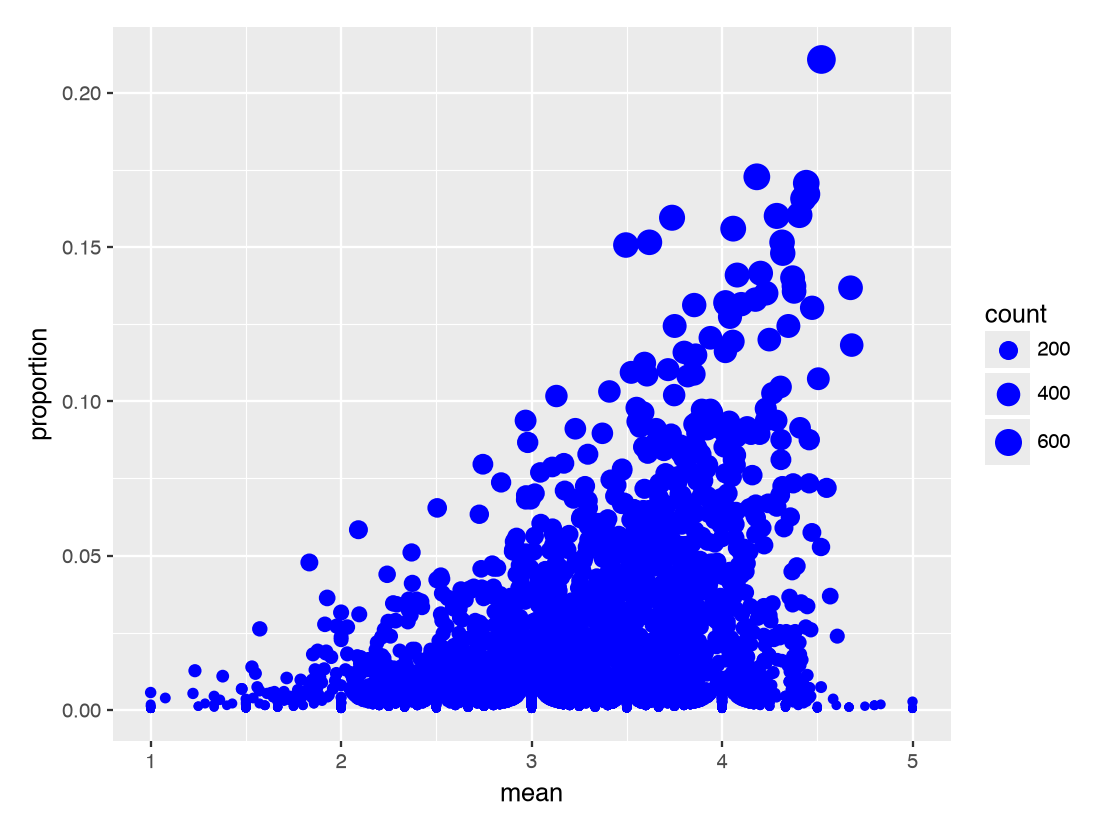

In [9]:
from plotnine import *
young_users_plot = (
    ggplot(young_avg, aes(x="mean", y="proportion", size = "count"))
    + geom_point(color="blue")
)

young_users_plot

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [10]:
# YOUR CODE HERE
ratings_per_movie = pd.merge(movie_data, rating_data, on="MovieID", how="left")
ratings_per_movie["Ratings_count"] = ratings_per_movie.groupby("MovieID")["Rating"].count()

len(ratings_per_movie[ratings_per_movie["Ratings_count"] == 0])

177

**177 movies have zero ratings. An inner join does not work for this situation because an inner join, by default, would only include movies that do have a rating, so a left join which includes movies that are not also reflected in the ratings table is necessary.**

6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [11]:
# YOUR CODE HERE
one_rating = rating_data[rating_data["Rating"] == 1].groupby("MovieID").size().rename("num_1_star_ratings")
five_rating = rating_data[rating_data["Rating"] == 5].groupby("MovieID").size().rename("num_5_star_ratings")
both = pd.merge(one_rating, five_rating, on="MovieID")
both = pd.merge(both, movie_data, on="MovieID")

len(both)

2986